<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Kala Ariadna Guevara


# Introducción
Para esta segunda instancia de trabajo, se elaboró el análisis y síntesis de señales que permitieron comprender de manera práctica los parámetros, operaciones y gráficos. Se experimentó con la modulación en amplitud, amplificación, desfase y clipping. Con el propósito de describir el trabajo de la forma más adecuada, se incluyeron las definiciones:

- La **modulación** consiste en variar la amplitud de la función senoidal principal en base a la otra señal de otra frecuencia.
- La **amplificación** comprende la modificación de la amplitud de la señal.
- Luego el **desfase** es desplazar la función en el tiempo.
- Y por último, el **clipping**, que se refiere a recortar la amplitud inicial de una señal.

Esto se elaboró con el propósito de visualizar cómo alteran la forma de onda y su representación matemática. A su vez, se pudo profundizar en la comprensión de las transformaciones que se pueden aplicar a las señales, algo útil para el futuro.
Una operación matemática utilizada en este trabajo es la **convolución**, que es una operación que se realiza a dos secuencias y se representa con un asterisco "*". A continuación se denotan la ecuación *(Ecuación 1)*. Esto es práctico porque, si conocés la respuesta al impulso, h[n], podés calcular la salida para cualquier entrada aplicando una única operación, la convolución.
    
Para poder clasificar y cuantificar señales periódicas o no periódicas, se utilizó la **energía total** *(Ecuación 2)* y la **potencia promedio** *(Ecuación 3)*. Por un lado, las señales no periódicas se describen por su energía total, que representa la “fuerza acumulada” a lo largo del tiempo. Mientras que las señales periódicas se caracterizan por su potencia promedio, que indica la energía transmitida por unidad de tiempo. 


#### **Ecuación 1**
<img src="./convolucion.png" width="300" /> 

#### **Ecuación 2: Energía total de una señal discreta**
Para una señal discreta \( x[n] \) de duración finita o no periódica:

$$
E = \sum_{n=-\infty}^{\infty} |x[n]|^2
$$

#### **Ecuación 3: Potencia promedio de una señal periódica**
Para una señal discreta \( x[n] \) periódica con periodo \( N \):

$$
P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2
$$

# Ejercicio 1

## Desarrollo y análisis

Para el desarrollo del trabajo práctico, en lugar de crear funciones propias como en mi primer intento, utilicé directamente herramientas de las librerías NumPy y SciPy, junto con Matplotlib para la visualización.

Primero definí los parámetros principales del sistema, como la frecuencia de la señal, la frecuencia de muestreo y el período de muestreo. A partir de esto generé los vectores de tiempo utilizando np.arange, lo que me permitió controlar con precisión la cantidad de muestras y la duración de cada señal. Luego construí las distintas señales solicitadas como fue explicado en clase y usando el diccionario de numpy como guia.

En cuanto a las operaciones desconocidas, la función np.where evalúa si la condición t_pulso < pulso es verdadera, si lo es coloca un 1. Pero si es falsa, coloca un 0. De este modo se genera un pulso rectangular que vale 1 desde t = 0 hasta t = 10 ms, en este caso, y después vale 0.

Adicionalmente, para modular la función base seno investigué qué es el parámetro m y qué es la frecuencia moduladora. El parámetro m es el índice de modulación en amplitud, es decir, controla la amplitud de la portadora (la señal de la función base) en función de la señal moduladora. Tener en cuenta que m va de 0 a 1. Y, por otro lado, la frecuencia moduladora (frecmoduladora) es la frecuencia de la señal que modula en amplitud a la portadora. En el gráfico se puede observar que la portadora queda envuelta por una sinusoidal de 1 kHz. Una vez obtenida la función modulada (x3) se le suma 1 a la moduladora para asegurarse de que la envolvente nunca cambie de signo. 

En general, esta parte del trabajo utilizó mucho del ts0, por ende, no se llegó a niveles altos de dificultad. En todos los casos, se generaron gráficos ajustando los límites de los ejes y utilizando grillas para mejorar la interpretación visual de las señales. Este enfoque permitió obtener gráficos más prolijos.

1) Seno 2 kHz
Periodo: 0.0005
Muestras: 250
Tipo: Señal de potencia



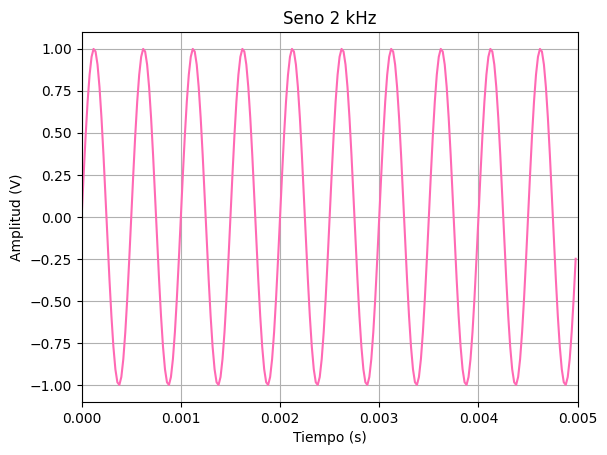

2) Amplificada 3 dB + fase
Periodo: 0.0005
Muestras: 250
Tipo: Señal de potencia



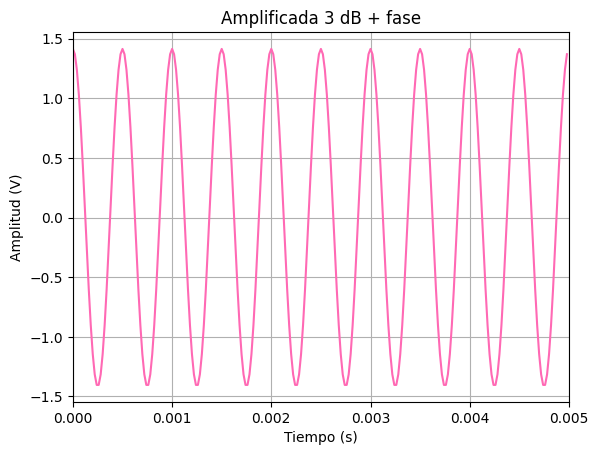

3) Modulada en amplitud
Periodo moduladora: 0.001
Muestras: 250
Tipo: Señal de potencia



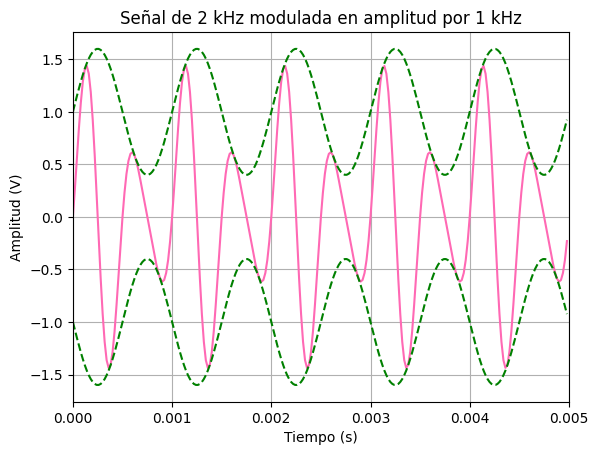

4) Señal clippeada 75%
Periodo: 0.0005
Muestras: 250
Tipo: Señal de potencia



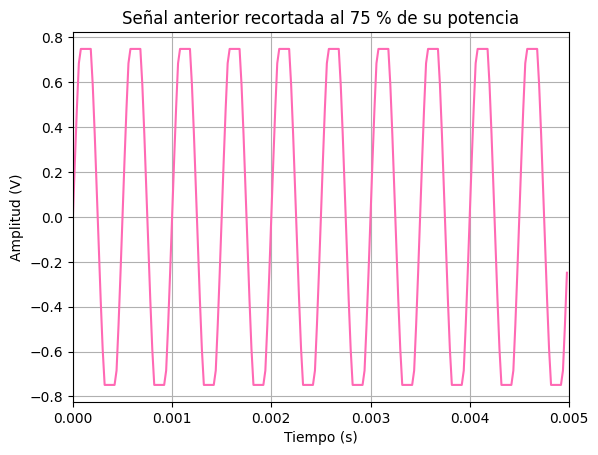

5) Cuadrada 4 kHz
Periodo: 0.00025
Muestras: 250
Tipo: Señal de potencia



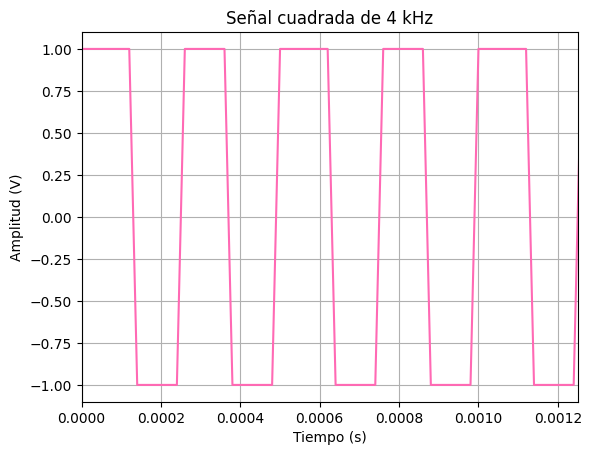

6) Pulso rectangular
Duración: 0.01
Muestras: 1000
Tipo: Señal de energia



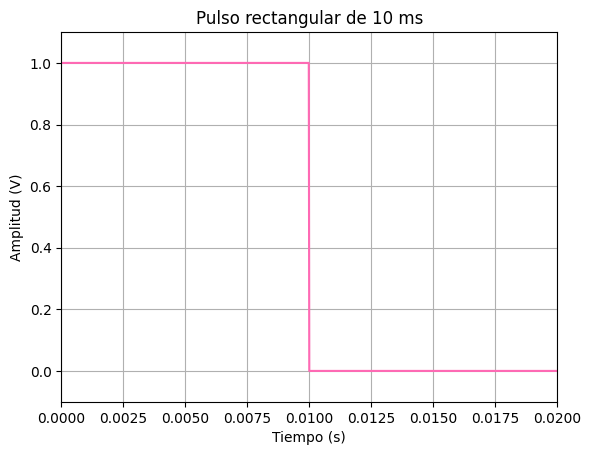

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

#Parametros
frec = 2000 #frecuencia en Hz de la señal principal
frec_muestreo = 50000  #frecuencia de muestreo [Hz]
Ts = 1/frec_muestreo   #tiempo entre muestras

# Vectores de tiempo usando arange
t_seno = np.arange(0, 0.005, Ts)       
t_cuadrada = np.arange(0, 0.005, Ts)   
t_pulso = np.arange(0, 0.02, Ts)        

#Una señal sinusoidal de 2KHz.
x1 = np.sin(2 * np.pi * frec * t_seno)
T1 = 1 / frec
N1 = len(t_seno)

print("1) Seno 2 kHz")
print("Periodo:", T1)
print("Muestras:", N1)
print("Tipo: Señal de potencia\n")

#Sus graficos
plt.figure(1)
plt.plot(t_seno, x1, color="hotpink")
plt.title('Seno 2 kHz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.xlim(0, 0.005)
plt.grid(True)
plt.show()

#2)Misma señal amplificada 3 dB y desfasada en π/2.
#3dB = sqrt(2)
x2 = np.sqrt(2) * np.sin(2 * np.pi * frec * t_seno + np.pi/2)

print("2) Amplificada 3 dB + fase")
print("Periodo:", T1)
print("Muestras:", N1)
print("Tipo: Señal de potencia\n")

#Sus graficos
plt.figure(2)
plt.plot(t_seno, x2, color="hotpink")
plt.title('Amplificada 3 dB + fase')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.xlim(0, 0.005)  
plt.grid(True)
plt.show()

#Misma señal pero modulada en amplitud por otra de la mitad de frecuencia
frecmoduladora = 1000  # señal moduladora
m = 0.6  # el índice m sirve para controlar que la amplitud no se vuelva negativa ni excesiva
#va de 0 a 1
x3 = (1 + m * np.sin(2 * np.pi * frecmoduladora * t_seno)) * x1
#portadora * (1 + moduladora), el 1 se suma para que la envolvente nunca cambie de signo.
#modulacion de amplitud clasica se escribe asi 
T3 = 1 / frecmoduladora

print("3) Modulada en amplitud")
print("Periodo moduladora:", T3)
print("Muestras:", N1)
print("Tipo: Señal de potencia\n")

#Sus graficos
plt.figure(3)
plt.plot(t_seno, x3, color="hotpink")
plt.title('Señal de 2 kHz modulada en amplitud por 1 kHz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.xlim(0, 0.005)  
plt.grid(True)

#Dibujo la envolvente
envolvente_superior = 1 + m * np.sin(2 * np.pi * frecmoduladora * t_seno)
envolvente_inferior = -(1 + m * np.sin(2 * np.pi * frecmoduladora * t_seno))
plt.plot(t_seno, envolvente_superior, 'g--')
plt.plot(t_seno, envolvente_inferior, 'g--')
plt.show()

#Señal anterior recortada al 75% de su amplitud
A = np.max(np.abs(x1))   #valor max de amp o.g
Aclip = 0.75 * A        #le saco el 75%
x1_clippeada = np.clip(x1, -Aclip, Aclip)

print("4) Señal clippeada 75%")
print("Periodo:", T1)
print("Muestras:", N1)
print("Tipo: Señal de potencia\n")

#Sus graficos
plt.figure(4)
plt.plot(t_seno, x1_clippeada, color="hotpink")
plt.title('Señal anterior recortada al 75 % de su potencia')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.xlim(0, 0.005)  
plt.grid(True)
plt.show()

#Señal cuadrada de 4 kHz
frec_cuadrada=4000
amp = 1    
x_cuadrada = amp * square(2 * np.pi * frec_cuadrada * t_cuadrada)
T5 = 1 / frec_cuadrada
N5 = len(t_cuadrada)

print("5) Cuadrada 4 kHz")
print("Periodo:", T5)
print("Muestras:", N5)
print("Tipo: Señal de potencia\n")

#Sus graficos
plt.figure(5)
plt.plot(t_cuadrada, x_cuadrada, color="hotpink")
plt.title('Señal cuadrada de 4 kHz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.xlim(0, 0.00125)  
plt.grid(True)
plt.show()

#para el pulso rectangular defino un tiempo más largo para que entre, porque si uso el que ya tenía definido se ve como el pulso de un muerto
pulso = 0.01
x_pulso = np.where(t_pulso < pulso, 1, 0)  # vale 1 de 0 a 10 ms, 0 después
N6 = len(t_pulso)

print("6) Pulso rectangular")
print("Duración:", pulso)
print("Muestras:", N6)
print("Tipo: Señal de energia\n")

#Sus graficos
plt.figure(6)
plt.plot(t_pulso, x_pulso, color="hotpink")
plt.title('Pulso rectangular de 10 ms')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.ylim(-0.1, 1.1)  # Para ver mejor los bordes
plt.xlim(0, 0.02)    # Para ver la transición  
plt.grid(True)
plt.show()

# Ejercicio 2

<img src="./consigna.jpg" width="700" /> 

In [2]:
from IPython.display import IFrame
IFrame("ejercicio.pdf", width=1000, height=1000)

## Conclusión y autoevaluación del aprendizaje
Para concluir, este trabajo permitió afianzar conceptos del análisis y la síntesis de señales, entre ellos la aplicación de herramientas de código y operaciones. Al amigarme más con estos conceptos se facilitó la comprensión de fenómenos como la modulación, la amplificación, el desfase y el clipping. Se verificó que la convolución constituye una herramienta fundamental para relacionar entrada, respuesta al impulso y salida, mostrando cómo, a partir de h[n], se puede reproducir el comportamiento completo del sistema. Es importante aclarar que la representación gráfica de cada caso confirmó la coherencia teórica y hizo más tangible las operaciones, facilitando la comprensión. En conjunto, las experiencias obtenidas constituyen una base sólida para seguir abordando trabajos en el área de señales.

Con respecto a mi experiencia personal resolví este tp con bastante seguridad, al principio tuve mis dudas ya que armé mis propias funciones en vez de usar las predeterminadas, pero luego todo se acomodó. Aprendí a cómo manipular señales, qué operaciones puedo aplicar y para qué me sirve. Por otro lado, me ayudó a repasar python y aprender nuevas maneras de codificar, ya que hay muchas funciones o operaciones nuevas. Para esto conté con la ayuda de chat gpt o deepseek, hay muchas operaciones en la biblioteca de scipy, numpy o matplotlib que son desconocidas para mí, en ese sentido, estaba bastante perdida, no obstante soy consciente de que simplifican la implementación y mejoran la precisión de los resultados. Adicionalmente, la inteligencia artificial me ayudó a corregir y redactar mis textos, especialmente errores de ortografía, tildes y sinónimos.

Como soy recursante aca va mi textito, honestamente el codigo me resulto muy sencillo, lo cual me agrada porque eso significa que lo entendi, le agregue la frecuencia moduladora por pintas. Por otro lado siento que, a diferencia del otro tp, este contaba con estos ejercicios a mano de la convolucion, vino barbaro para empezar a usa lapiz y papel y practicar. Con ayuda de unos videos de youtube, tambien creo que logre entender mejor la convolucion y la respuesta al impulso, honestamente no tuve tiempo para armar un resumen... pero lo haré proximamente...

# Biblografía
- Holton, T. (2021). Digital signal processing: Principles and applications. Cambridge University Press. https://doi.org/10.1017/9781108290050
- NumPy user guide — NumPy v2.3 Manual. (2025). Numpy.org. https://numpy.org/doc/stable/user/index.html
- Signal processing (scipy.signal) — SciPy v1.16.1 Manual. (2025). Scipy.org. https://docs.scipy.org/doc/scipy/reference/signal.html#waveforms